# LFM Instance Segmentation Example Workflow
This notebook trains a Graha/Lunar-FM Mask R-CNN instance segmentation model for crater detection. It loads a split crater instance dataset, builds the Graha object-detection datamodule and TerraTorch task, runs fine-tuning, writes checkpoints, and creates validation prediction plots.

## Purpose of this notebook
Use this notebook as the active interactive Graha instance-segmentation training workflow. The values in the **User Configuration** section mirror the most commonly changed command-line options; lower-level options stay on the centralized experiment-config defaults unless they are explicitly promoted into that section.

**Note**: the default configuration assumes 7-band WAC data. For NAC data (IMP and NAC crater datasets), change `DATASET_MODALITY` to `"nac"` and set `BAND_FILTER` to the NAC band indices you want to use.


## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import lfm

from functools import partialmethod
from glob import glob
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
from lightning.pytorch import seed_everything
from tqdm import tqdm

tqdm.__init__ = partialmethod(tqdm.__init__, disable=False)

In [15]:
repo_root = Path.cwd().parents[2]
NOTEBOOK_DIR = repo_root / "notebooks" / "full_model"

if not (repo_root / "lfm").exists():
  raise FileNotFoundError(
      "Cannot find lfm/ directory. Run this notebook from "
      "lfm/notebooks/full_model or update repo_root."
  )

from lfm.all_models.all_tasks.utils import (
  create_timestamped_output_dir,
  plot_instance_cache_predictions,
  save_graha_instance_prediction_cache,
)
from lfm.all_models.inst_seg import build_graha_notebook_configs
from lfm.full_model.inst_seg import instance_graha_components

print("Successfully imported LFM modules")

Successfully imported LFM modules


## User Configuration

These are the values a notebook user is expected to edit for a normal Graha instance-segmentation run.

#### Paths
`BASE_OUTPUT_DIR`: parent directory for timestamped notebook outputs. Checkpoints, config files, prediction caches, and plots are written under a new timestamped subdirectory.

`DATA_ROOT`: split dataset root. It should contain `train/`, `val/`, and `test/` folders, each with `chips/` and `labels/` subfolders.

`PRETRAIN_DIR`: Graha/Lunar-FM pretraining directory. It must contain `checkpoints/checkpoint_weights_final.pt`, `full_config.yaml`, and `modality_info.yaml`.

`LIGHTNING_CHECKPOINT`: optional Graha Lightning checkpoint to resume from. Leave as `None` for a fresh fine-tune.

#### Data Selection
`DATASET_MODALITY`: dataset-level modality hint. `"wac"` resolves Graha input mode to `"vis-uv"` and normalization modality to `"vis_uv"`; `"nac"` resolves both to single-modality NAC behavior.

`BAND_FILTER`: input band indices to keep. The default `[0, 1, 2, 3, 4, 5, 6]` uses all WAC VIS+UV channels.

`MAX_TRAIN_SAMPLES`, `MAX_VAL_SAMPLES`, `MAX_TEST_SAMPLES`: optional split caps for quick experiments. Set any of these to `None` to use the full split.

#### Training
`BATCH_SIZE`: Graha training batch size.

`NUM_WORKERS`: dataloader worker count.

`MAX_EPOCHS`: number of fine-tuning epochs.

`GRAHA_BACKBONE_LR`, `GRAHA_HEAD_LR`, `GRAHA_LAYER_DECAY`, `GRAHA_WEIGHT_DECAY`, `GRAHA_WARMUP_STEPS`: Graha optimizer schedule parameters.

#### Defaults Kept In Code
The notebook leaves these centralized defaults unchanged unless you add them to the config cell: `TARGET_SIZE=256`, `IMAGE_GLOB="*chip*.tif"`, `LABEL_GLOB="*label.*"`, `IMAGE_SUFFIX=None`, `LABEL_SUFFIX=None`, `GRAHA_STATS_BATCH_SIZE=16`, `GRAHA_VIS_UV_MERGE_METHOD="mean"`, `GRAHA_ANCHOR_SIZES=[[8], [16], [32], [64]]`, `GRAHA_ANCHOR_ASPECT_RATIOS=[0.5, 1.0, 2.0]`, `GRAHA_SCORE_THRESHOLD=0.5`, `PLOT_EVERY_N_EPOCHS=1`, `PLOT_N_SAMPLES=5`, `PREDICTION_SPLIT="val"`, `PREDICTION_N_SAMPLES=5`, `PREDICTION_SCORE_THRESHOLD=0.5`, `MASK_SHIFT=(0, 0)`, `IGNORE_NODATA_IN_LOSS=False`, `NODATA_IGNORE_INDEX=-1`, `SEED=42`.


In [4]:
BASE_OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "instance_seg_finetuning"
DATA_ROOT = "/explore/nobackup/projects/lfm/model_inputs/300_300_inputs/full_model_inst_seg_v2"
PRETRAIN_DIR = "/explore/nobackup/projects/lfm/ibm_model_pretrain_dir"
LIGHTNING_CHECKPOINT = None

DATASET_MODALITY = "wac"
BAND_FILTER = [0, 1, 2, 3, 4, 5, 6]
MAX_TRAIN_SAMPLES = 500
MAX_VAL_SAMPLES = 500
MAX_TEST_SAMPLES = 500

BATCH_SIZE = 8
NUM_WORKERS = 10
MAX_EPOCHS = 1

GRAHA_BACKBONE_LR = 5.0e-5
GRAHA_HEAD_LR = 2.0e-4
GRAHA_LAYER_DECAY = 0.75
GRAHA_WEIGHT_DECAY = 0.05
GRAHA_WARMUP_STEPS = 500

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


The configuration cell above mirrors the active Graha instance-segmentation training settings. Values not listed there use the centralized defaults documented in the previous markdown cell.


In [5]:
OUTPUT_DIR = create_timestamped_output_dir(BASE_OUTPUT_DIR)

notebook_configs = build_graha_notebook_configs(
    output_dir=OUTPUT_DIR,
    data_root=DATA_ROOT,
    base_output_dir=OUTPUT_DIR,
    graha_pretrain_dir=PRETRAIN_DIR,
    graha_lightning_checkpoint=LIGHTNING_CHECKPOINT,
    dataset_modality=DATASET_MODALITY,
    max_epochs=MAX_EPOCHS,
    graha_batch_size=BATCH_SIZE,
    graha_num_workers=NUM_WORKERS,
    band_filter=BAND_FILTER,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_val_samples=MAX_VAL_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
    graha_backbone_lr=GRAHA_BACKBONE_LR,
    graha_head_lr=GRAHA_HEAD_LR,
    graha_layer_decay=GRAHA_LAYER_DECAY,
    graha_weight_decay=GRAHA_WEIGHT_DECAY,
    graha_warmup_steps=GRAHA_WARMUP_STEPS,
)

config = notebook_configs.experiment_config
graha_config = notebook_configs.graha_config
deps = notebook_configs.dependencies

seed_everything(config.seed)
instance_graha_components.save_config(graha_config, OUTPUT_DIR)

print("Config created successfully")
print(f"Data root: {config.data_root}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Graha modality mode: {config.graha_input_modality_mode}")
print(f"Normalization modality: {config.normalization_modality}")

Using output subdir: /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48
PROJ_DATA = /explore/nobackup/projects/lfm/lfm-full-env/share/proj
GDAL_DATA = /explore/nobackup/projects/lfm/lfm-full-env/share/gdal


/explore/nobackup/projects/lfm/lfm-full-env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[rank: 0] Seed set to 42


Config created successfully
Data root: /panfs/ccds02/nobackup/projects/lfm/model_inputs/300_300_inputs/full_model_inst_seg_v2
Output dir: /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48
Graha modality mode: vis-uv
Normalization modality: vis_uv


## Output Directory
The timestamped output directory was created while building the config. It contains the saved config, checkpoints, prediction caches, and plots for this run.


In [6]:
print(f"Notebook output directory: {OUTPUT_DIR}")

Notebook output directory: /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48


## Create datamodule
1. Load pretraining stats from .yaml file
2. Create datamodule using pretraining stats and other config options

In [7]:
# STEP 1: pretraining stats
print("\nSTEP 1: Loading pretraining stats...")
print("="*60)

datamodule_cls = deps["GrahaObjectDetectionInstanceDataModule"]
means, stds = instance_graha_components.get_normalization_stats(
    graha_config,
    datamodule_cls,
)

print("Done.")


STEP 1: Loading pretraining stats...
TerraMind WAC pretraining mean: [0.0262588825351396, 0.0355034864633048, 0.0379165676944608, 0.0398220978887433, 0.0425382088988623, 0.0176056219925766, 0.0208237419578931]
TerraMind WAC pretraining std: [0.0235771438796118, 0.0304743769950188, 0.0321657294809433, 0.033536663068166, 0.0355271969090003, 0.0161019641570903, 0.018979149243733]
Done.


In [8]:
print("\nSTEP 2: Creating datamodule and inspecting one training batch...")
print("=" * 60)

graha_datamodule = instance_graha_components.create_datamodule(
    graha_config,
    datamodule_cls,
    means,
    stds,
)
graha_sample_batch = instance_graha_components.inspect_batch(graha_datamodule)

print("Done.")


STEP 2: Creating datamodule and inspecting one training batch...
[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[train] Found 496 matched image-label pairs
[train] Dataset configured for 7 channel(s)
[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[val] Found 26 matched image-label pairs
[val] Dataset configured for 7 channel(s)
batch keys: dict_keys(['image', 'boxes', 'labels', 'masks', 'filename', 'mask', 'crater_boxes', 'num_craters'])
image: (8, 7, 256, 256) torch.float32
batch image per-band mean: [0.11649490892887115, 0.1293836236000061, 0.12747035920619965, 0.1266125589609146, 0.12597867846488953, 0.01727326214313507, 0.012862831354141235]
batch image per-band std: [0.4917885363101959, 0.49444523453712463, 0.486344575881958, 0.4804431200027466, 0.479996919631958, 0.4088921546936035, 0.3870704770088196]
boxes per image: [(47, 4), (3, 4), (20, 4), (19, 4), (65, 4), (36, 4), (66, 4), (4, 4)]
labels per image: [(47,), (3,), (20,), (19,), (65,), (36,), (66,), (4

## Create Terratorch Task Object, Model

In [9]:
task_cls = instance_graha_components.make_downstream_object_detection_task_class(
    deps["LunarObjectDetectionTask"]
)

graha_task = instance_graha_components.create_task(
    graha_config,
    task_cls,
    graha_sample_batch,
)
instance_graha_components.run_loss_smoke(graha_task, graha_sample_batch)

WAC channels registered for model: 7
Graha input modality mode: vis-uv
Backbone modalities: ['vis', 'uv']
Backbone merge method: mean
LunarBackbone: using modality_info.yaml from '/panfs/ccds02/nobackup/projects/lfm/ibm_model_pretrain_dir/modality_info.yaml' (20 modalities: ['aspect', 'aspect_3m', 'dtm', 'dtm_3m', 'metadata', 'nac', 'slope', 'slope_3m', 'static_maps', 'tok_aspect', 'tok_aspect_3m', 'tok_dtm', 'tok_dtm_3m', 'tok_nac', 'tok_slope', 'tok_slope_3m', 'tok_uv', 'tok_vis', 'uv', 'vis'])


/explore/nobackup/projects/lfm/lfm-full-env/lib/python3.12/site-packages/terratorch/tasks/object_detection_task.py:85: UserWarning: The Object Detection Task has to be considered experimental. This is less mature than the other tasks and being further improved.
  warnings.warn(


Auto-detected num_register_tokens=0 from checkpoint
encoder_embeddings.aspect.mod_emb
encoder_embeddings.aspect.pos_emb
encoder_embeddings.aspect.proj.weight
encoder_embeddings.aspect_3m.mod_emb
encoder_embeddings.aspect_3m.pos_emb
encoder_embeddings.aspect_3m.proj.weight
encoder_embeddings.dtm.mod_emb
encoder_embeddings.dtm.pos_emb
encoder_embeddings.dtm.proj.weight
encoder_embeddings.dtm_3m.mod_emb
encoder_embeddings.dtm_3m.pos_emb
encoder_embeddings.dtm_3m.proj.weight
encoder_embeddings.metadata.mod_emb
encoder_embeddings.metadata.pos_emb
encoder_embeddings.metadata.token_emb.weight
encoder_embeddings.nac.mod_emb
encoder_embeddings.nac.pos_emb
encoder_embeddings.nac.proj.weight
encoder_embeddings.slope.mod_emb
encoder_embeddings.slope.pos_emb
encoder_embeddings.slope.proj.weight
encoder_embeddings.slope_3m.mod_emb
encoder_embeddings.slope_3m.pos_emb
encoder_embeddings.slope_3m.proj.weight
encoder_embeddings.static_maps.mod_emb
encoder_embeddings.static_maps.pos_emb
encoder_embedding

## Run Training

In [10]:
trainer = instance_graha_components.create_trainer(graha_config, OUTPUT_DIR)
print(trainer)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
print("\n" + "=" * 60)
print("Starting training.")
print("=" * 60)

ckpt_path = (
    str(graha_config.lightning_checkpoint)
    if graha_config.lightning_checkpoint is not None
    else None
)
trainer.fit(
    graha_task,
    datamodule=graha_datamodule,
    ckpt_path=ckpt_path,
)

print("Finished training.")


Starting training.
[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[train] Found 496 matched image-label pairs
[train] Dataset configured for 7 channel(s)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[val] Found 26 matched image-label pairs
[val] Dataset configured for 7 channel(s)


Loading `train_dataloader` to estimate number of stepping batches.


[LunarObjectDetectionTask] 17 param groups, 223.2M trainable params. layer_decay=0.75 backbone_lr=5e-05 head_lr=0.0002
  backbone_layer_0_nd              lr=1.19e-06 wd=0.00e+00 n=21,504
  backbone_layer_0_wd              lr=1.19e-06 wd=5.00e-02 n=114,199,296
  backbone_layer_10_wd             lr=2.11e-05 wd=5.00e-02 n=7,079,424
  backbone_layer_11_wd             lr=2.81e-05 wd=5.00e-02 n=7,079,424
  backbone_layer_12_wd             lr=3.75e-05 wd=5.00e-02 n=7,079,424
  backbone_layer_13_nd             lr=5.00e-05 wd=0.00e+00 n=768
  backbone_layer_1_wd              lr=1.58e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_2_wd              lr=2.11e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_3_wd              lr=2.82e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_4_wd              lr=3.75e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_5_wd              lr=5.01e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_6_wd              lr=6.67e-06 wd=5.00e-02 n=7,079,424
  backbone_layer_7_wd              l

...

[Graha] validation started

[Graha] validation finished

[Graha] train epoch 1 finished in 109.3s

`Trainer.fit` stopped: `max_epochs=1` reached.


Finished training.


## Create And Display Validation Visualizations
Training writes checkpoint files during `trainer.fit()`. This section saves a small prediction cache on the configured split and renders the resulting plot in the notebook.


In [12]:
prediction_cache = save_graha_instance_prediction_cache(
    task=graha_task,
    datamodule=graha_datamodule,
    output_dir=OUTPUT_DIR,
    model_name="graha",
    split=config.prediction_split,
    n_samples=config.prediction_n_samples,
    score_threshold=config.prediction_score_threshold,
)

prediction_plot = plot_instance_cache_predictions(
    prediction_cache,
    OUTPUT_DIR / "plots" / "single_model" / "graha_model",
    model_name="graha",
    n_samples=config.prediction_n_samples,
    filename=f"{config.prediction_split}_instance_predictions.png",
)
print(f"Saved prediction plot: {prediction_plot}")

[train] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[train] Found 496 matched image-label pairs
[train] Dataset configured for 7 channel(s)
[val] Filtered inputs to channels: [0, 1, 2, 3, 4, 5, 6]
[val] Found 26 matched image-label pairs
[val] Dataset configured for 7 channel(s)
Saved 5 graha instance prediction cache file(s) to /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48/prediction_cache/graha/val
Saved instance cache plot to /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48/plots/single_model/graha_model/val_instance_predictions.png
Saved prediction plot: /explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/instance_seg_finetuning/date_2026_07_31-time_10_40_48/plots/single_model/graha_model/val_instance_predictions.png


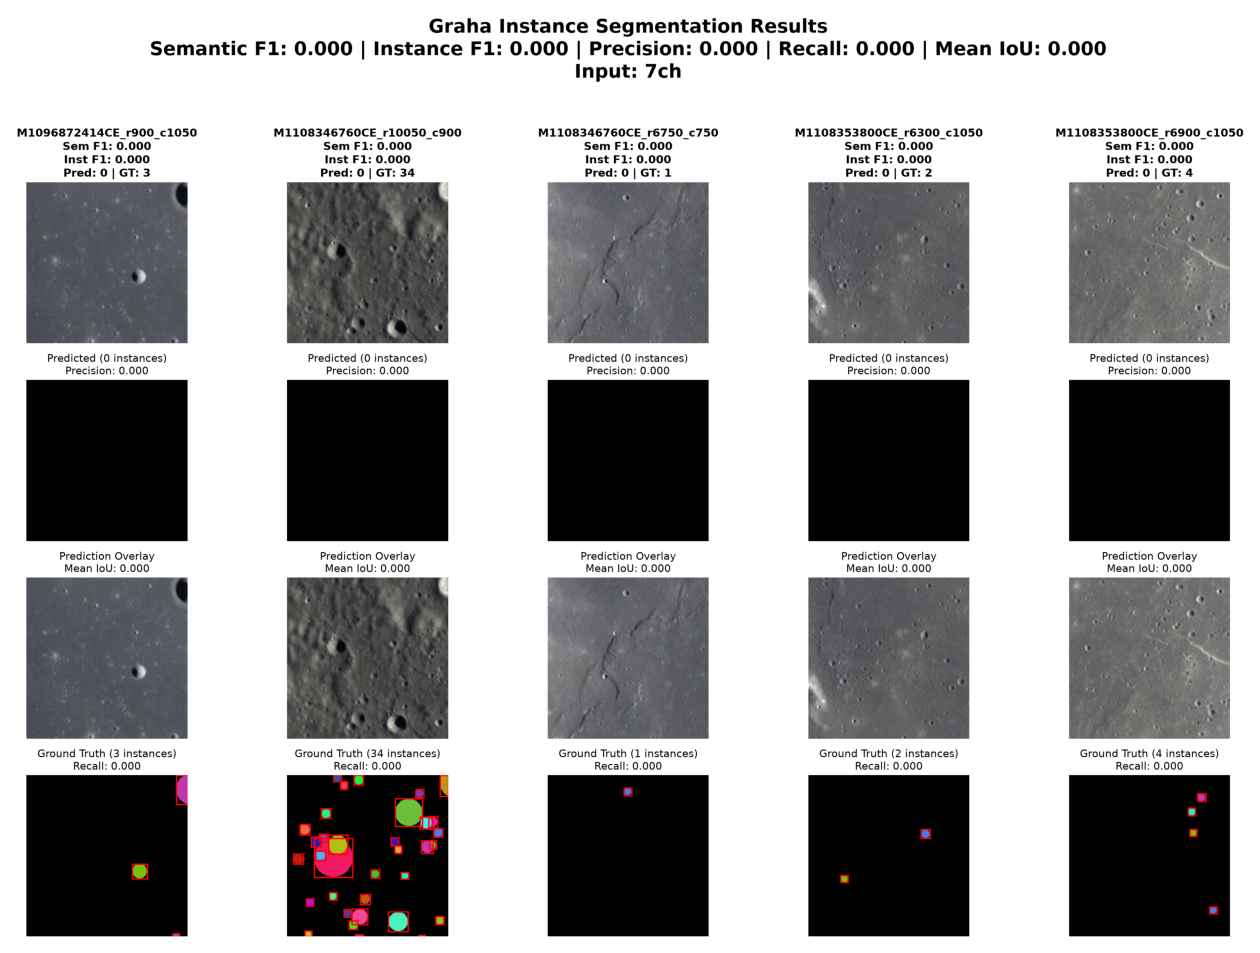

In [13]:
img = mpimg.imread(prediction_plot)
plt.figure(figsize=(16, 14))
plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
del graha_task, graha_datamodule, trainer
if torch.cuda.is_available():
    torch.cuda.empty_cache()